# EDA — Paso 2: Enriquecimiento con `bureau.csv`

**Objetivo:** Traer información del historial crediticio externo hacia `application_train`.

En este Paso 2 vamos a:
1. Explorar `bureau.csv` (créditos que el cliente tuvo en OTROS bancos)
2. Crear agregaciones por cliente (`SK_ID_CURR`)
3. Unir con `application_train` 
4. Analizar si las nuevas features mejoran la separación de la TARGET

**Regla:** Cada merge debe tener una justificación de negocio clara.

---
## 1. Setup

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup listo.')

Setup listo.


---
## 2. Carga de datos

Cargamos ambas tablas. `bureau.csv` tiene UNA fila por crédito previo del cliente en otros bancos.

**Pregunta de negocio:** Un cliente con muchos créditos externos en default es más riesgoso.

La clave de unión es `SK_ID_CURR`.

In [52]:
app_train = pd.read_csv('../data/raw/application_train.csv')
bureau = pd.read_csv('../data/raw/bureau.csv')

print('=== application_train ===')
print(f'Filas:    {app_train.shape[0]:,}')
print(f'Columnas: {app_train.shape[1]}')
print(f'IDs:      {app_train["SK_ID_CURR"].nunique():,}')
print()
print('=== bureau ===')
print(f'Filas:    {bureau.shape[0]:,}')
print(f'Columnas: {bureau.shape[1]}')
print(f'IDs:      {bureau["SK_ID_CURR"].nunique():,}')

=== application_train ===
Filas:    307,511
Columnas: 122
IDs:      307,511

=== bureau ===
Filas:    1,716,428
Columnas: 17
IDs:      305,811


In [53]:
# Cuántos créditos por cliente en bureau
credits_per_client = bureau.groupby('SK_ID_CURR').size()

print('Créditos por cliente (en otros bancos):')
print(credits_per_client.describe())
print(f'\nClientes sin crédito externo: {app_train["SK_ID_CURR"].nunique() - bureau["SK_ID_CURR"].nunique():,}')
print(f'Clientes con crédito externo: {bureau["SK_ID_CURR"].nunique():,}')

Créditos por cliente (en otros bancos):
count   305811.0000
mean         5.6127
std          4.4304
min          1.0000
25%          2.0000
50%          4.0000
75%          8.0000
max        116.0000
dtype: float64

Clientes sin crédito externo: 1,700
Clientes con crédito externo: 305,811


In [54]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,91323.0000,0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0000,NaN,NaN,0,225000.0000,171342.0000,NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,464323.5000,NaN,NaN,0.0000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0000,NaN,NaN,0.0000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0000,NaN,77674.5000,0,2700000.0000,NaN,NaN,0.0000,Consumer credit,-21,NaN


---
## 3. Estructura de bureau

In [55]:
bureau.info()

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB


In [56]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1716428.0000,1716428.0000,1716428.0000,1716428.0000,1610875.0000,1082775.0000,591940.0000,1716428.0000,1716415.0000,1458759.0000,1124648.0000,1716428.0000,1716428.0000,489637.0000
mean,278214.9336,5924434.4890,-1142.1077,0.8182,510.5174,-1017.4371,3825.4177,0.0064,354994.5919,137085.1200,6229.5150,37.9128,-593.7483,15712.7577
std,102938.5581,532265.7286,795.1649,36.5444,4994.2198,714.0106,206031.6062,0.0962,1149811.3440,677401.1310,45032.0315,5937.6500,720.7473,325826.9491
min,100001.0000,5000000.0000,-2922.0000,0.0000,-42060.0000,-42023.0000,0.0000,0.0000,0.0000,-4705600.3200,-586406.1150,0.0000,-41947.0000,0.0000
25%,188866.7500,5463953.7500,-1666.0000,0.0000,-1138.0000,-1489.0000,0.0000,0.0000,51300.0000,0.0000,0.0000,0.0000,-908.0000,0.0000
50%,278055.0000,5926303.5000,-987.0000,0.0000,-330.0000,-897.0000,0.0000,0.0000,125518.5000,0.0000,0.0000,0.0000,-395.0000,0.0000
75%,367426.0000,6385681.2500,-474.0000,0.0000,474.0000,-425.0000,0.0000,0.0000,315000.0000,40153.5000,0.0000,0.0000,-33.0000,13500.0000
max,456255.0000,6843457.0000,0.0000,2792.0000,31199.0000,0.0000,115987185.0000,9.0000,585000000.0000,170100000.0000,4705600.3200,3756681.0000,372.0000,118453423.5000


In [57]:
bureau.describe(include='object')

,CREDIT_ACTIVE,CREDIT_CURRENCY,CREDIT_TYPE
count,1716428,1716428,1716428
unique,4,4,15
top,Closed,currency 1,Consumer credit
freq,1079273,1715020,1251615


---
## 4. Calidad de datos de bureau

In [58]:
# Nulos
nulls = bureau.isnull().sum()
nulls_pct = (nulls / len(bureau) * 100).round(2)

null_df = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct}).query('nulos > 0').sort_values('pct', ascending=False)
print(f'Columnas con nulos: {len(null_df)} de {bureau.shape[1]}')
null_df

Columnas con nulos: 7 de 17


,nulos,pct
AMT_ANNUITY,1226791,71.4700
AMT_CREDIT_MAX_OVERDUE,1124488,65.5100
DAYS_ENDDATE_FACT,633653,36.9200
AMT_CREDIT_SUM_LIMIT,591780,34.4800
AMT_CREDIT_SUM_DEBT,257669,15.0100
DAYS_CREDIT_ENDDATE,105553,6.1500
AMT_CREDIT_SUM,13,0.0000


In [59]:
# Distribución de CREDIT_ACTIVE (estado del crédito)
print('ESTADO DE CRÉDITOS EXTERNOS:')
print(bureau['CREDIT_ACTIVE'].value_counts())
print()
print(bureau['CREDIT_ACTIVE'].value_counts(normalize=True) * 100)

ESTADO DE CRÉDITOS EXTERNOS:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

CREDIT_ACTIVE
Closed     62.8790
Active     36.7395
Sold        0.3803
Bad debt    0.0012
Name: proportion, dtype: float64


In [60]:
# Distribución de CREDIT_TYPE
print('TIPOS DE CRÉDITO EXTERNO:')
print(bureau['CREDIT_TYPE'].value_counts())

TIPOS DE CRÉDITO EXTERNO:
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64


---
## 5. Agregaciones por cliente

**La clave del enriquecimiento:** cada cliente en `bureau` tiene MÚLTIPLES créditos. Necesitamos comprimirlos en UNA fila por cliente.

Estrategia:
1. Agregaciones numéricas (conteo, sumas, promedios, máximos)
2. One-hot encoding de categorías (proporciones de estado)

Esto es lo que se llama **feature engineering a nivel cliente**.

In [61]:
# === AGREGACIONES NUMÉRICAS ===
num_agg = bureau.groupby('SK_ID_CURR').agg({
    # Conteo de créditos
    'SK_ID_BUREAU': 'count',
    
    # Montos
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean'],
    'AMT_CREDIT_SUM_OVERDUE': 'sum',
    'AMT_CREDIT_MAX_OVERDUE': 'max',
    'AMT_ANNUITY': ['mean', 'max'],
    
    # Tiempos
    'DAYS_CREDIT': ['mean', 'min', 'max'],
    'CREDIT_DAY_OVERDUE': ['mean', 'max'],
    'DAYS_CREDIT_UPDATE': 'mean',
    
    # Otros
    'CNT_CREDIT_PROLONG': 'sum',
})

# Aplanar columnas multi-index
num_agg.columns = ['_'.join(col).strip() for col in num_agg.columns]
num_agg = num_agg.reset_index()

print(f'Clientes con agregaciones numéricas: {num_agg.shape[0]:,}')
print(f'Features generadas: {num_agg.shape[1] - 1}')
num_agg.head()

Clientes con agregaciones numéricas: 305,811
Features generadas: 17


,SK_ID_CURR,SK_ID_BUREAU_count,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_max,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_CREDIT_MAX_OVERDUE_max,AMT_ANNUITY_mean,AMT_ANNUITY_max,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,CREDIT_DAY_OVERDUE_mean,CREDIT_DAY_OVERDUE_max,DAYS_CREDIT_UPDATE_mean,CNT_CREDIT_PROLONG_sum
0,100001,7,1453365.0000,207623.5714,378000.0000,596686.5000,85240.9286,0.0000,NaN,3545.3571,10822.5000,-735.0000,-1572,-49,0.0000,0,-93.1429,0
1,100002,8,865055.5650,108131.9456,450000.0000,245781.0000,49156.2000,0.0000,5043.6450,0.0000,0.0000,-874.0000,-1437,-103,0.0000,0,-499.8750,0
2,100003,4,1017400.5000,254350.1250,810000.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,-1400.7500,-2586,-606,0.0000,0,-816.0000,0
3,100004,2,189037.8000,94518.9000,94537.8000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,-867.0000,-1326,-408,0.0000,0,-532.0000,0
4,100005,3,657126.0000,219042.0000,568800.0000,568408.5000,189469.5000,0.0000,0.0000,1420.5000,4261.5000,-190.6667,-373,-62,0.0000,0,-54.3333,0


In [62]:
# === PROPORCIONES DE ESTADO (one-hot → proporciones) ===
active_dummies = pd.get_dummies(bureau[['SK_ID_CURR', 'CREDIT_ACTIVE']])

# Sumar por cliente y dividir por total de créditos para obtener proporción
active_agg = active_dummies.groupby('SK_ID_CURR').sum().reset_index()

# Agregar el total para calcular proporciones después
total_credits = bureau.groupby('SK_ID_CURR').size().reset_index(name='TOTAL_CREDITS')
active_agg = active_agg.merge(total_credits, on='SK_ID_CURR')

# Calcular proporciones (las columnas se llaman CREDIT_ACTIVE_Closed, etc.)
active_cols = [c for c in active_agg.columns if c.startswith('CREDIT_ACTIVE_')]
for col in active_cols:
    active_agg[f'{col}_pct'] = active_agg[col] / active_agg['TOTAL_CREDITS']

print('Proporciones de estado calculadas:')
print(f'Columnas generadas: {active_cols}')
active_agg.head()

Proporciones de estado calculadas:
Columnas generadas: ['CREDIT_ACTIVE_Active', 'CREDIT_ACTIVE_Bad debt', 'CREDIT_ACTIVE_Closed', 'CREDIT_ACTIVE_Sold']


,SK_ID_CURR,CREDIT_ACTIVE_Active,CREDIT_ACTIVE_Bad debt,CREDIT_ACTIVE_Closed,CREDIT_ACTIVE_Sold,TOTAL_CREDITS,CREDIT_ACTIVE_Active_pct,CREDIT_ACTIVE_Bad debt_pct,CREDIT_ACTIVE_Closed_pct,CREDIT_ACTIVE_Sold_pct
0,100001,3,0,4,0,7,0.4286,0.0000,0.5714,0.0000
1,100002,2,0,6,0,8,0.2500,0.0000,0.7500,0.0000
2,100003,1,0,3,0,4,0.2500,0.0000,0.7500,0.0000
3,100004,0,0,2,0,2,0.0000,0.0000,1.0000,0.0000
4,100005,2,0,1,0,3,0.6667,0.0000,0.3333,0.0000


In [63]:
# === PROPORCIONES DE TIPO DE CRÉDITO ===
type_dummies = pd.get_dummies(bureau[['SK_ID_CURR', 'CREDIT_TYPE']])

type_agg = type_dummies.groupby('SK_ID_CURR').sum().reset_index()
type_agg = type_agg.merge(total_credits, on='SK_ID_CURR')

type_cols = [c for c in type_agg.columns if c.startswith('CREDIT_TYPE_')]
for col in type_cols:
    type_agg[f'{col}_pct'] = type_agg[col] / type_agg['TOTAL_CREDITS']

print(f'Proporciones de tipo calculadas: {len(type_cols)} tipos')

Proporciones de tipo calculadas: 15 tipos


In [64]:
# === FEATURES DERIVADAS (de negocio) ===
derived = bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT': 'count',
    'CREDIT_DAY_OVERDUE': lambda x: (x > 0).sum(),  # Créditos con overdue
    'AMT_CREDIT_SUM_DEBT': lambda x: (x > 0).sum(),  # Créditos con deuda
})
derived.columns = ['bureau_total_credits', 'bureau_credits_overdue', 'bureau_credits_with_debt']
derived = derived.reset_index()

# Ratios de negocio
derived['bureau_overdue_rate'] = derived['bureau_credits_overdue'] / derived['bureau_total_credits']
derived['bureau_debt_rate'] = derived['bureau_credits_with_debt'] / derived['bureau_total_credits']

print('Features derivadas de negocio:')
derived.head()

Features derivadas de negocio:


,SK_ID_CURR,bureau_total_credits,bureau_credits_overdue,bureau_credits_with_debt,bureau_overdue_rate,bureau_debt_rate
0,100001,7,0,3,0.0000,0.4286
1,100002,8,0,1,0.0000,0.1250
2,100003,4,0,0,0.0000,0.0000
3,100004,2,0,0,0.0000,0.0000
4,100005,3,0,2,0.0000,0.6667


---
## 6. Merge con application_train

Unimos todas las agregaciones a la tabla central.

In [65]:
# Merge secuencial
df = app_train.copy()

df = df.merge(num_agg, on='SK_ID_CURR', how='left')
df = df.merge(active_agg[['SK_ID_CURR'] + [c for c in active_agg.columns if c.startswith('CREDIT_ACTIVE_') or c == 'TOTAL_CREDITS']], 
              on='SK_ID_CURR', how='left')
df = df.merge(type_agg[['SK_ID_CURR'] + [c for c in type_agg.columns if c.startswith('CREDIT_TYPE_') and c.endswith('_pct')]], 
              on='SK_ID_CURR', how='left')
df = df.merge(derived, on='SK_ID_CURR', how='left')

print(f'Shape final: {df.shape}')
print(f'Nuevas columnas: {df.shape[1] - app_train.shape[1]}')
print(f'Columnas totales: {df.shape[1]}')

Shape final: (307511, 168)
Nuevas columnas: 46
Columnas totales: 168


In [66]:
# Verificar nulos en las nuevas features
new_cols = [c for c in df.columns if c not in app_train.columns]
new_nulls = df[new_cols].isnull().sum().sort_values(ascending=False)
new_nulls_pct = (new_nulls / len(df) * 100).round(2)

print('Nulos en nuevas features (los que no tenían crédito externo):')
null_report = pd.DataFrame({'nulos': new_nulls, 'pct': new_nulls_pct})
null_report.head(20)

Nulos en nuevas features (los que no tenían crédito externo):


,nulos,pct
AMT_ANNUITY_mean,227502,73.9800
AMT_ANNUITY_max,227502,73.9800
AMT_CREDIT_MAX_OVERDUE_max,123625,40.2000
AMT_CREDIT_SUM_DEBT_mean,51380,16.7100
AMT_CREDIT_SUM_max,44021,14.3200
AMT_CREDIT_SUM_mean,44021,14.3200
AMT_CREDIT_SUM_DEBT_sum,44020,14.3100
AMT_CREDIT_SUM_sum,44020,14.3100
SK_ID_BUREAU_count,44020,14.3100
AMT_CREDIT_SUM_OVERDUE_sum,44020,14.3100


---
## 7. Análisis de features enriquecidas vs TARGET

La pregunta clave: **¿las features de bureau ayudan a separar pagadores de defaults?**

In [67]:
# Correlaciones de las nuevas features con la TARGET
TARGET_COL = 'TARGET'

corr_with_target = df[new_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

print('=== TOP 15 POSITIVAS (mayor riesgo de default) ===')
print(corr_with_target.sort_values(ascending=False).head(15))
print()
print('=== TOP 10 NEGATIVAS (menor riesgo) ===')
print(corr_with_target.sort_values(ascending=True).head(10))

=== TOP 15 POSITIVAS (mayor riesgo de default) ===
DAYS_CREDIT_mean              0.0897
bureau_debt_rate              0.0781
CREDIT_ACTIVE_Active_pct      0.0774
bureau_credits_with_debt      0.0765
DAYS_CREDIT_min               0.0752
DAYS_CREDIT_UPDATE_mean       0.0689
CREDIT_ACTIVE_Active          0.0671
DAYS_CREDIT_max               0.0498
CREDIT_TYPE_Microloan_pct     0.0444
bureau_credits_overdue        0.0420
CREDIT_TYPE_Credit card_pct   0.0347
bureau_overdue_rate           0.0319
CREDIT_ACTIVE_Sold_pct        0.0165
AMT_CREDIT_SUM_OVERDUE_sum    0.0133
CREDIT_ACTIVE_Sold            0.0121
Name: TARGET, dtype: float64

=== TOP 10 NEGATIVAS (menor riesgo) ===
CREDIT_ACTIVE_Closed_pct                        -0.0794
CREDIT_ACTIVE_Closed                            -0.0308
CREDIT_TYPE_Consumer credit_pct                 -0.0263
CREDIT_TYPE_Mortgage_pct                        -0.0209
CREDIT_TYPE_Car loan_pct                        -0.0201
AMT_CREDIT_SUM_mean                         

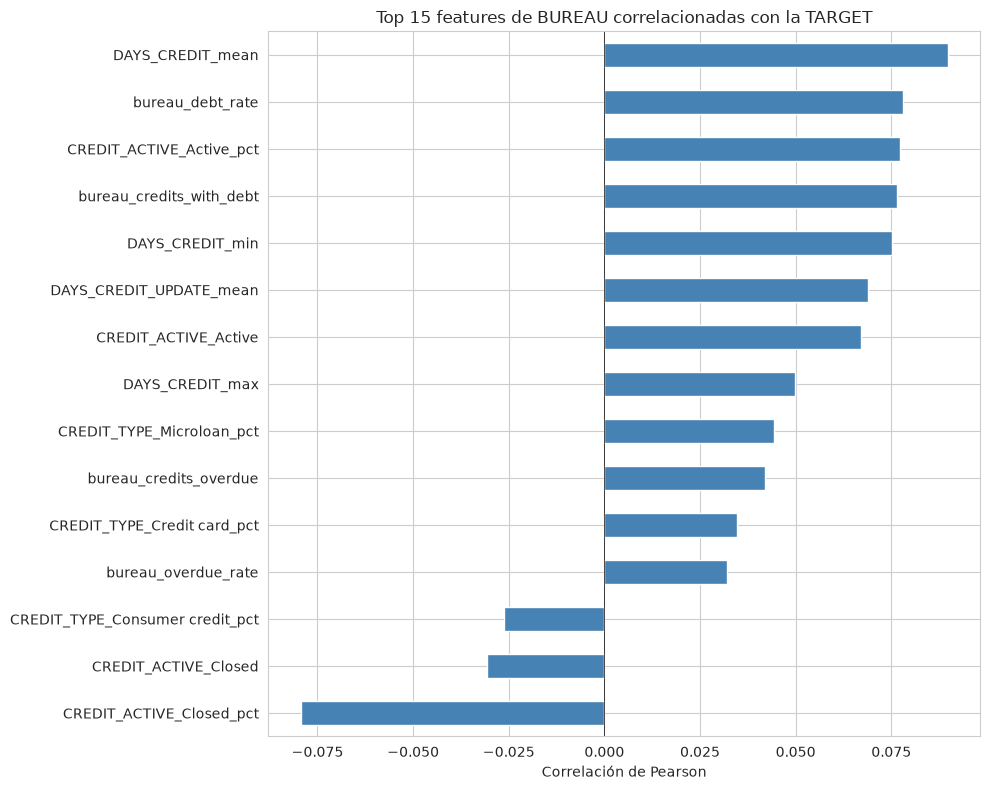

In [68]:
# Visualización: Top features correlacionadas con TARGET
top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)
top_features = top_corr.index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target[top_features].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 features de BUREAU correlacionadas con la TARGET')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

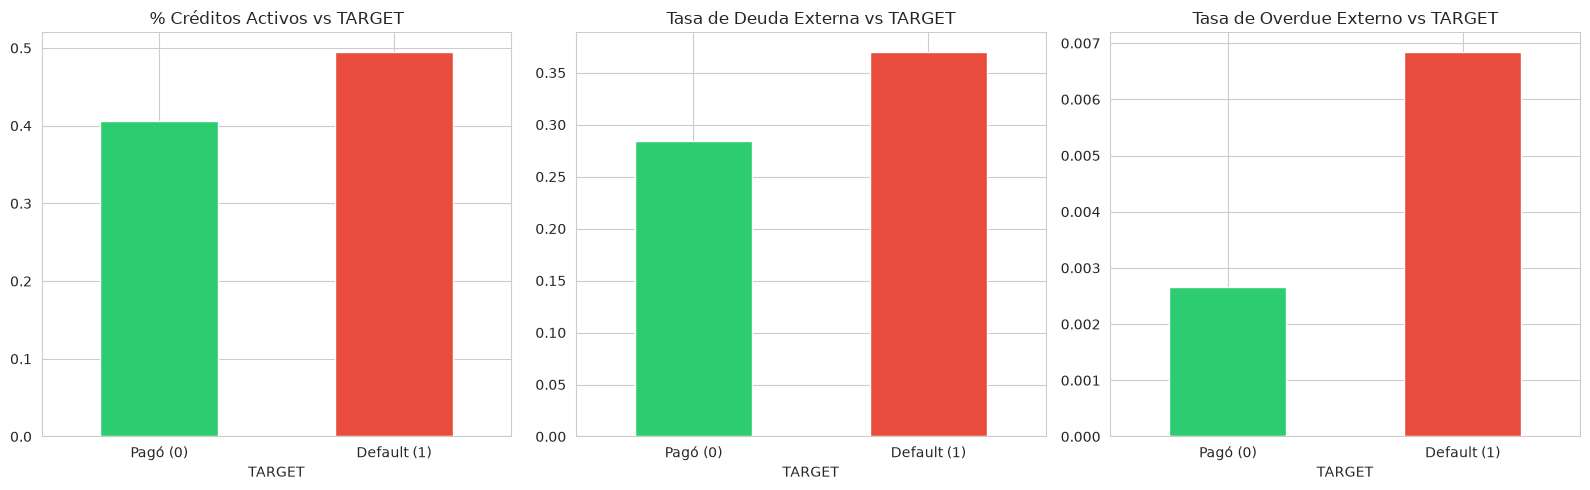

In [69]:
# Comparar distribución de TARGET por estado de crédito
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Créditos activos vs default
# Buscar la columna de créditos activos (%)
active_pct_col = [c for c in df.columns if 'CREDIT_ACTIVE_Active' in c and c.endswith('_pct')]
if active_pct_col:
    df.groupby(TARGET_COL)[active_pct_col[0]].mean().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('% Créditos Activos vs TARGET')
    axes[0].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

# Créditos con deuda vs default
if 'bureau_debt_rate' in df.columns:
    df.groupby(TARGET_COL)['bureau_debt_rate'].mean().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Tasa de Deuda Externa vs TARGET')
    axes[1].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

# Overdue rate vs default
if 'bureau_overdue_rate' in df.columns:
    df.groupby(TARGET_COL)['bureau_overdue_rate'].mean().plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'])
    axes[2].set_title('Tasa de Overdue Externo vs TARGET')
    axes[2].set_xticklabels(['Pagó (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()

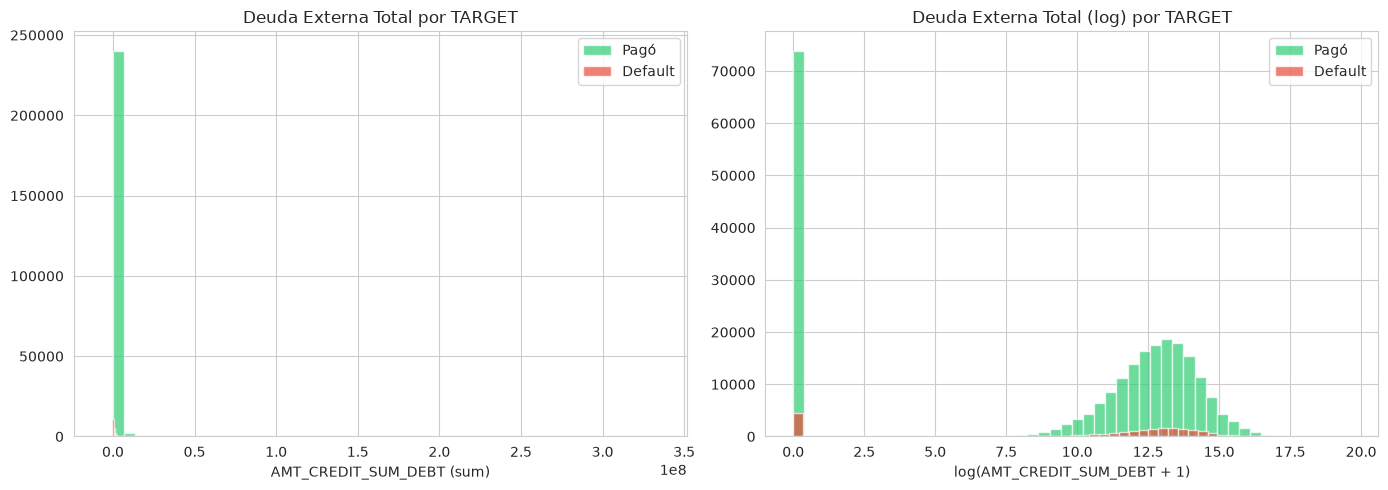

In [70]:
# Distribución de AMT_CREDIT_SUM_DEBT (deuda externa) por TARGET
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sin log (para ver la escala real)
df[df[TARGET_COL] == 0]['AMT_CREDIT_SUM_DEBT_sum'].hist(bins=50, ax=axes[0], alpha=0.7, label='Pagó', color='#2ecc71')
df[df[TARGET_COL] == 1]['AMT_CREDIT_SUM_DEBT_sum'].hist(bins=50, ax=axes[0], alpha=0.7, label='Default', color='#e74c3c')
axes[0].set_title('Deuda Externa Total por TARGET')
axes[0].set_xlabel('AMT_CREDIT_SUM_DEBT (sum)')
axes[0].legend()

# Con log para ver mejor
df[df[TARGET_COL] == 0]['AMT_CREDIT_SUM_DEBT_sum'].clip(lower=0).apply(np.log1p).hist(bins=50, ax=axes[1], alpha=0.7, label='Pagó', color='#2ecc71')
df[df[TARGET_COL] == 1]['AMT_CREDIT_SUM_DEBT_sum'].clip(lower=0).apply(np.log1p).hist(bins=50, ax=axes[1], alpha=0.7, label='Default', color='#e74c3c')
axes[1].set_title('Deuda Externa Total (log) por TARGET')
axes[1].set_xlabel('log(AMT_CREDIT_SUM_DEBT + 1)')
axes[1].legend()

plt.tight_layout()
plt.show()

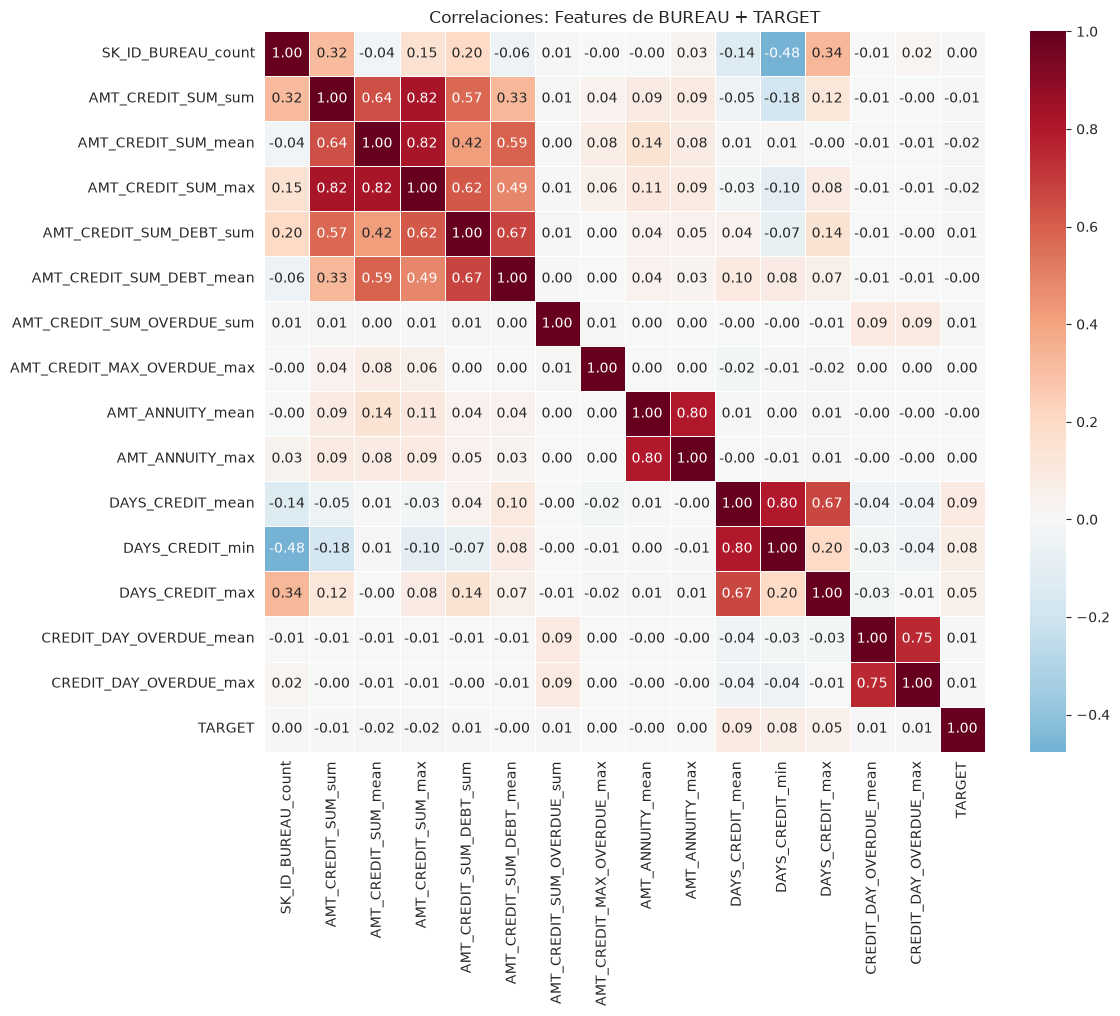

In [71]:
# Heatmap de correlaciones entre features de bureau y TARGET
bureau_features = [c for c in new_cols if not c.startswith('CREDIT_TYPE_')][:15]
bureau_features.append(TARGET_COL)

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[bureau_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones: Features de BUREAU + TARGET')
plt.tight_layout()
plt.show()

---
## 8. Impacto en la TARGET

Comparar: ¿qué porcentaje de clientes con crédito externo tienen default vs los que no?

In [72]:
# Clientes CON crédito externo vs SIN
has_bureau = df['TOTAL_CREDITS'].notna()

print('=== IMPACTO DEL CRÉDITO EXTERNO EN LA TARGET ===')
print()
print(f'Con crédito externo:  {has_bureau.sum():,} clientes')
print(f'  Default rate:       {df[has_bureau][TARGET_COL].mean()*100:.2f}%')
print()
print(f'Sin crédito externo:  {(~has_bureau).sum():,} clientes')
print(f'  Default rate:       {df[~has_bureau][TARGET_COL].mean()*100:.2f}%')

=== IMPACTO DEL CRÉDITO EXTERNO EN LA TARGET ===

Con crédito externo:  263,491 clientes
  Default rate:       7.73%

Sin crédito externo:  44,020 clientes
  Default rate:       10.12%


In [73]:
# Default rate por rango de deuda externa
df['debt_range'] = pd.cut(df['AMT_CREDIT_SUM_DEBT_sum'].fillna(-1), 
                          bins=[-1, 0, 50000, 200000, 1000000, float('inf')],
                          labels=['Sin deuda', 'Baja', 'Media', 'Alta', 'Muy alta'])

print('Default rate por nivel de deuda externa:')
debt_default = df.groupby('debt_range')[TARGET_COL].agg(['mean', 'count'])
debt_default.columns = ['default_rate', 'n_clients']
debt_default['default_rate'] = debt_default['default_rate'] * 100
debt_default

Default rate por nivel de deuda externa:


,default_rate,n_clients
debt_range,,
Sin deuda,5.6963,77068
Baja,7.9394,18931
Media,7.9803,41352
Alta,8.8563,79401
Muy alta,9.0009,45462


---
## 9. Guardar dataset enriquecido

Guardamos el dataset enriquecido para usarlo en pasos posteriores.

In [74]:
# Guardar para uso futuro
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/application_train_bureau.csv', index=False)
print(f'Guardado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Guardado: 307,511 filas x 169 columnas


---
## 10. Hallazgos y conclusiones


In [76]:
print('RESUMEN DEL EDA - Paso 2 (Bureau)')
print('=' * 50)
print()
print('1. BUREAU:')
print(f'   - {bureau.shape[0]:,} créditos externos registrados')
print(f'   - {bureau["SK_ID_CURR"].nunique():,} clientes con crédito externo')
print()
print('2. FEATURES GENERADAS:')
print(f'   - {len(new_cols)} nuevas features agregadas')
print()
print('3. TOP CORRELACIONES CON TARGET:')
top5 = corr_with_target.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = '+' if corr_with_target[feat] > 0 else '-'
    print(f'   - {feat}: {direction}{val:.4f}')
print()
print('4. IMPACTO:')
if has_bureau.sum() > 0:
    rate_with = df[has_bureau][TARGET_COL].mean()*100
    rate_without = df[~has_bureau][TARGET_COL].mean()*100
    print(f'   - Default rate con crédito externo: {rate_with:.2f}%')
    print(f'   - Default rate sin crédito externo: {rate_without:.2f}%')
print()
print('5. PRÓXIMOS PASOS:')
print('   - Paso 3: Agregar previous_application.csv (préstamos internos)')

RESUMEN DEL EDA - Paso 2 (Bureau)

1. BUREAU:
   - 1,716,428 créditos externos registrados
   - 305,811 clientes con crédito externo

2. FEATURES GENERADAS:
   - 46 nuevas features agregadas

3. TOP CORRELACIONES CON TARGET:
   - DAYS_CREDIT_mean: +0.0897
   - CREDIT_ACTIVE_Closed_pct: -0.0794
   - bureau_debt_rate: +0.0781
   - CREDIT_ACTIVE_Active_pct: +0.0774
   - bureau_credits_with_debt: +0.0765

4. IMPACTO:
   - Default rate con crédito externo: 7.73%
   - Default rate sin crédito externo: 10.12%

5. PRÓXIMOS PASOS:
   - Paso 3: Agregar previous_application.csv (préstamos internos)
